<a href="https://colab.research.google.com/github/elyssaayu/heart-failure-prediction/blob/main/notebooks/Heart_Failure_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Setup and Data Cleaning**

In [ ]:
import sqlite3
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt # we only need pyplot

# Basic style
sb.set_theme(style="white", palette="muted")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["figure.dpi"] = 120

file_path = '/content/drive/MyDrive/Project 1 - Heart Failure Prediction/heart.csv'

raw_df = pd.read_csv(file_path)
conn = sqlite3.connect('heart_disease.db')
raw_df.to_sql('patient_records', conn, if_exists='replace', index=False)

# Select needed columns via SQL
sql_query = """
SELECT
    Age,
    ChestPainType,
    RestingBP,
    Cholesterol,
    FastingBS,
    RestingECG,
    MaxHR,
    Oldpeak,
    CASE WHEN Sex = 'M' THEN 1 ELSE 0 END AS Male,
    CASE WHEN ExerciseAngina = 'Y' THEN 1 ELSE 0 END AS Angina,
    CASE WHEN ST_Slope = 'Up' THEN 1 ELSE 0 END AS SlopeUp,
    -- Target Variable
    HeartDisease
FROM patient_records
"""

heart_df = pd.read_sql(sql_query, conn)
conn.close()
heart_df.head()

,Age,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,Oldpeak,Male,Angina,SlopeUp,HeartDisease
0,40,ATA,140,289,0,Normal,172,0.0,1,0,1,0
1,49,NAP,160,180,0,Normal,156,1.0,0,0,0,1
2,37,ATA,130,283,0,ST,98,0.0,1,0,1,0
3,48,ASY,138,214,0,Normal,108,1.5,0,1,0,1
4,54,NAP,150,195,0,Normal,122,0.0,1,0,1,0


In [ ]:
import seaborn as sns

# Calculate the number of missing values for each column in the original DataFrame
missing_values_count = heart_df.isnull().sum()

# Filter out columns that have 0 missing values for clarity
missing_values_count = missing_values_count[missing_values_count > 0]

# Check if there are any missing values to plot
if not missing_values_count.empty:
  # Create a bar plot
    fig = plt.figure(figsize=(12, 7))
    sns.barplot(x=missing_values_count.index, y=missing_values_count.values, palette='viridis')
    plt.title('Number of Missing Values Per Column')
    plt.xlabel('Columns')
    plt.ylabel('Number of Missing Values')
    plt.xticks(rotation=45, ha='right') # Rotate column names for better readability
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in any column.")

No missing values found in any column.


/tmp/ipykernel_648/1192560677.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=zero_values_count.index, y=zero_values_count.values, palette='viridis')


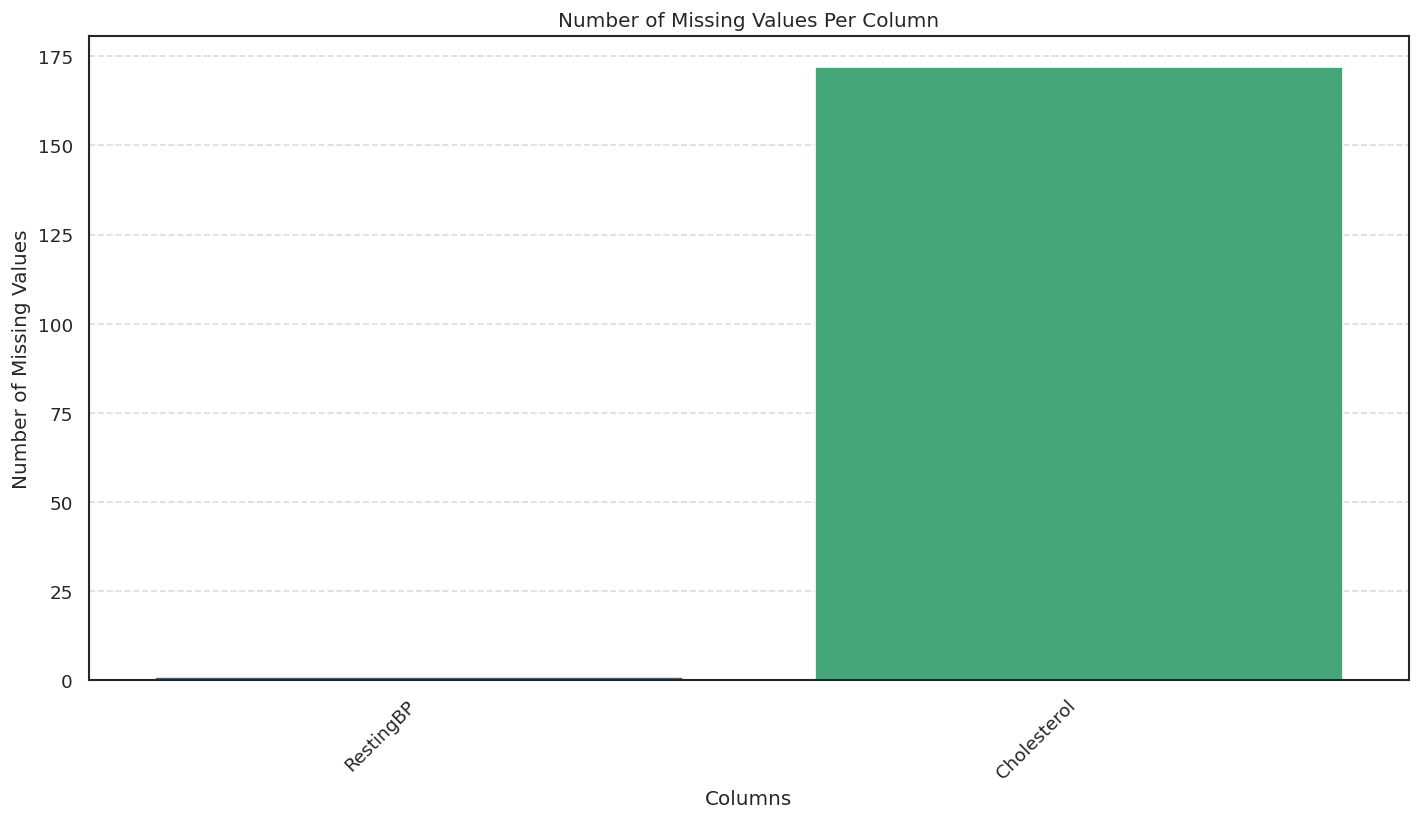

In [ ]:
# Calculate the number of zero values for each column in the original DataFrame
numeric_cols = heart_df[['Age', 'RestingBP', 'Cholesterol', 'MaxHR']]
zero_values_count = (numeric_cols == 0).sum()

zero_values_count = zero_values_count[zero_values_count > 0]
if not zero_values_count.empty:
    fig = plt.figure(figsize=(12, 7))
    sns.barplot(x=zero_values_count.index, y=zero_values_count.values, palette='viridis')
    plt.title('Number of Zero-Value Entries Per Column')
    plt.xlabel('Columns')
    plt.ylabel('Number of Zero-Value Entries')
    plt.xticks(rotation=45, ha='right') # Rotate column names for better readability
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in any column.")

In [ ]:
print(zero_values_count)

RestingBP        1
Cholesterol    172
dtype: int64


In [ ]:
# Replace Cholesterol values of 0 with median according to Heart_Disease or not
heart_df['Cholesterol'] = heart_df['Cholesterol'].replace(0, np.nan)
heart_df['Cholesterol'] = heart_df['Cholesterol'].fillna(heart_df.groupby('HeartDisease')['Cholesterol'].transform('median'))

heart_df['RestingBP'] = heart_df['RestingBP'].replace(0, np.nan)
heart_df['RestingBP'] = heart_df['RestingBP'].fillna(heart_df.groupby('HeartDisease')['RestingBP'].transform('median'))

In [ ]:
# One-Hot Encode Chest Pain Types
heart_df = pd.get_dummies(heart_df, columns=['ChestPainType'], drop_first=True)

# One-Hot Encode RestingECG Types
heart_df = pd.get_dummies(heart_df, columns=['RestingECG'], drop_first=True)

In [ ]:
heart_df.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Male,Angina,SlopeUp,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST
0,40,140.0,289.0,0,172,0.0,1,0,1,0,True,False,False,True,False
1,49,160.0,180.0,0,156,1.0,0,0,0,1,False,True,False,True,False
2,37,130.0,283.0,0,98,0.0,1,0,1,0,True,False,False,False,True
3,48,138.0,214.0,0,108,1.5,0,1,0,1,False,False,False,True,False
4,54,150.0,195.0,0,122,0.0,1,0,1,0,False,True,False,True,False


In [ ]:
heart_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                918 non-null    int64  
 1   RestingBP          918 non-null    float64
 2   Cholesterol        918 non-null    float64
 3   FastingBS          918 non-null    int64  
 4   MaxHR              918 non-null    int64  
 5   Oldpeak            918 non-null    float64
 6   Male               918 non-null    int64  
 7   Angina             918 non-null    int64  
 8   SlopeUp            918 non-null    int64  
 9   HeartDisease       918 non-null    int64  
 10  ChestPainType_ATA  918 non-null    bool   
 11  ChestPainType_NAP  918 non-null    bool   
 12  ChestPainType_TA   918 non-null    bool   
 13  RestingECG_Normal  918 non-null    bool   
 14  RestingECG_ST      918 non-null    bool   
dtypes: bool(5), float64(3), int64(7)
memory usage: 76.3 KB


## **Exploratory Data Analysis and Hypothesis Testing**

In [ ]:
# Set global theme and typography
sns.set_theme(style="white")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["figure.dpi"] = 120

# Unified palette: Blue = Healthy (0), Orange = Heart Disease (1)
CUSTOM_PALETTE = {0: "#2b5c8f", 1: "#d95f02"}


def plot_unified_kde(
    data,
    x_col,
    hue_col="HeartDisease",
    title="Distribution Plot",
    xlabel="Value",
    palette=CUSTOM_PALETTE,
):
    """Generates a standardized KDE distribution plot for report consistency."""
    fig, ax = plt.subplots(figsize=(8, 5))

    # KDE Plot
    sns.kdeplot(
        data=data,
        x=x_col,
        hue=hue_col,
        fill=True,
        common_norm=False,  # Normalizes curves independently
        palette=palette,
        alpha=0.35,  # Soft transparency for overlaps
        linewidth=1.8,
        ax=ax,
    )

    # Clean borders (spines)
    sns.despine(top=True, right=True, left=False, bottom=False)

    # Subtle horizontal grid
    ax.yaxis.grid(True, linestyle="--", alpha=0.5, color="#cccccc")
    ax.set_axisbelow(True)

    # Titles & Labels
    ax.set_title(title, fontsize=12, fontweight="bold", pad=15, color="#222222")
    ax.set_xlabel(xlabel, fontsize=10, labelpad=10, color="#444444")
    ax.set_ylabel("Density", fontsize=10, labelpad=10, color="#444444")

    # Legend Customization (if hue column is present)
    if hue_col and ax.get_legend():
        legend = ax.get_legend()
        legend.set_title("Heart Disease")
        # Replace 0 and 1 with readable labels
        for text in legend.get_texts():
            if text.get_text() == "0":
                text.set_text("Healthy (0)")
            elif text.get_text() == "1":
                text.set_text("Diagnosed (1)")

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_648/3712573406.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=heart_df['HeartDisease'], palette='viridis')


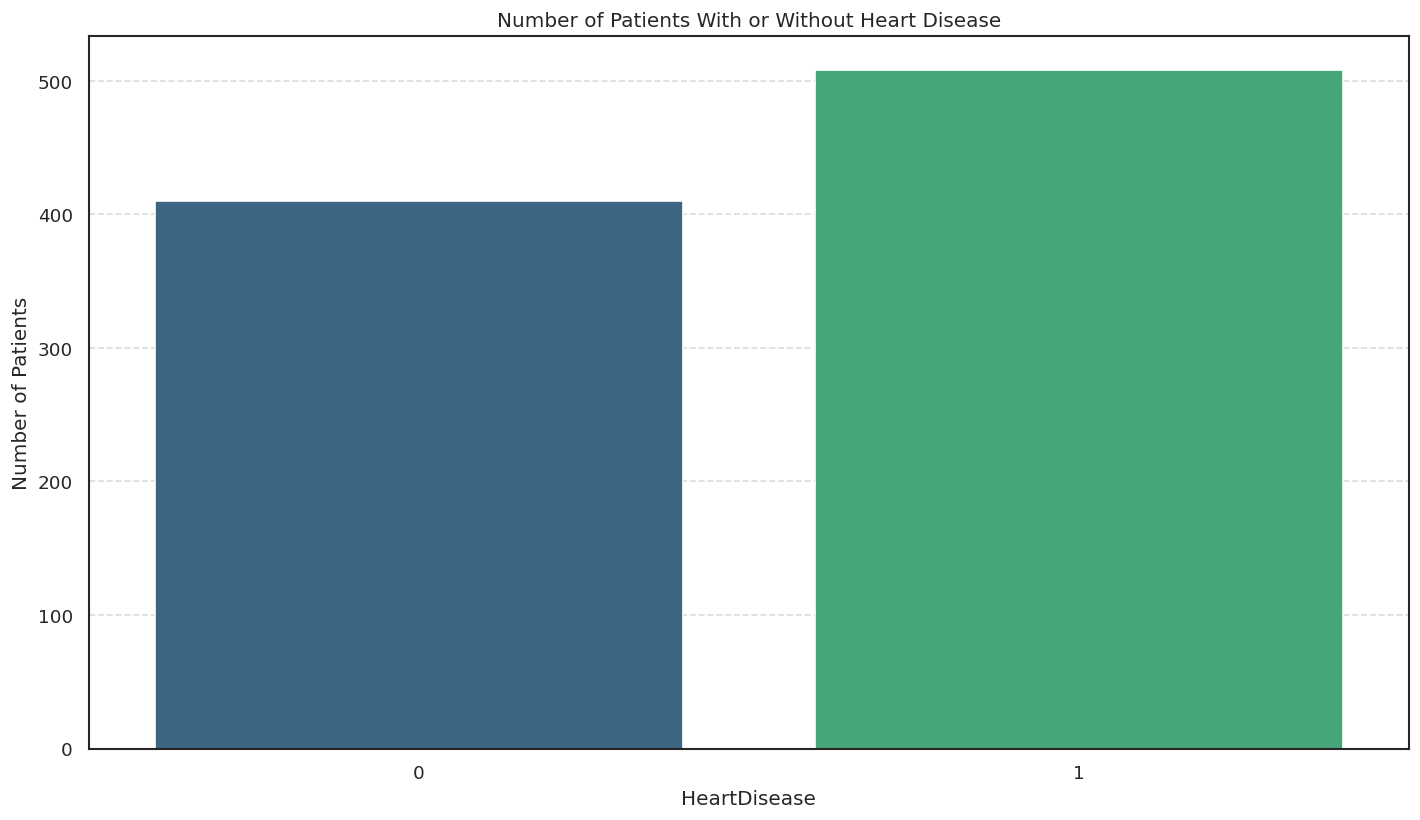

In [ ]:
# Quite equal, suitable to use for classification
fig = plt.figure(figsize=(12, 7))
sns.countplot(x=heart_df['HeartDisease'], palette='viridis')
plt.title('Number of Patients With or Without Heart Disease')
plt.ylabel('Number of Patients')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_648/3822894211.py:22: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.kdeplot(


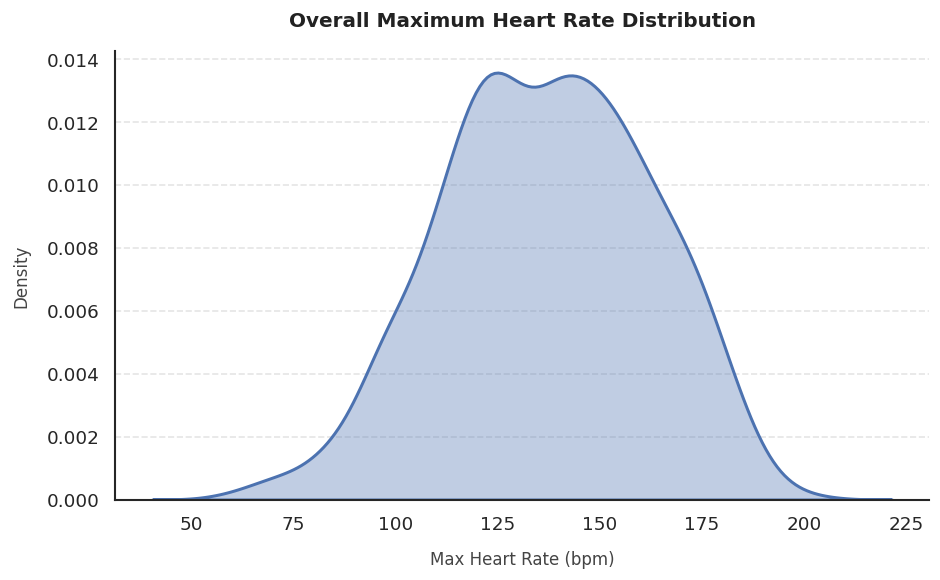

In [ ]:
plot_unified_kde(
    data=heart_df,
    x_col="MaxHR",
    hue_col=None,  # Single distribution without split
    title="Overall Maximum Heart Rate Distribution",
    xlabel="Max Heart Rate (bpm)",
    palette={"MaxHR": "#2b5c8f"},
)

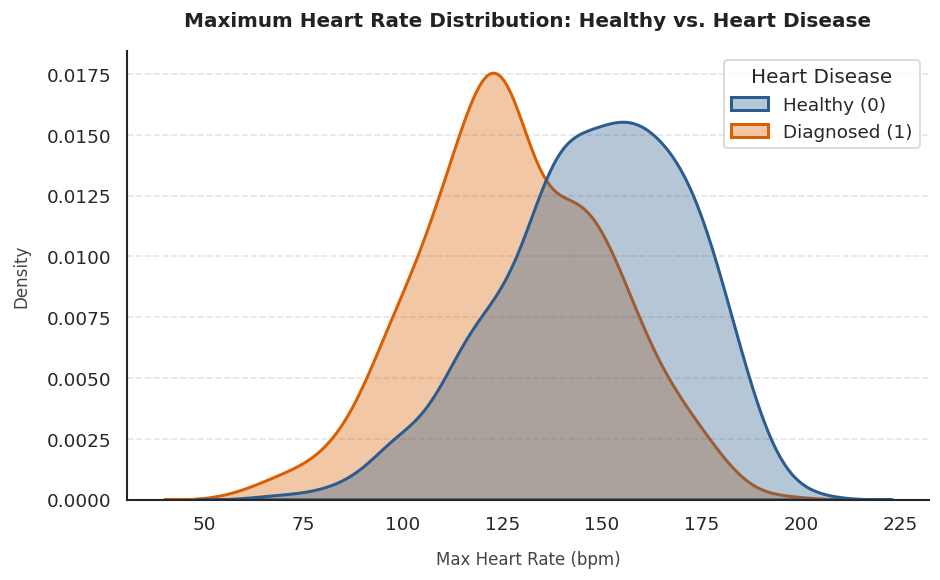

In [ ]:
plot_unified_kde(
    data=heart_df,
    x_col="MaxHR",
    hue_col="HeartDisease",
    title="Maximum Heart Rate Distribution: Healthy vs. Heart Disease",
    xlabel="Max Heart Rate (bpm)",
)

In [ ]:
# Hypothesis Testing: Is the MaxHR of heart disease patients less than that of healthy patients?
# H0: There is no statistical significance in the difference between the MaxHR of heart disease patients and healthy patients.

from scipy.stats import t

healthy_maxhr = heart_df[heart_df['HeartDisease'] == 0]['MaxHR']
disease_maxhr = heart_df[heart_df['HeartDisease'] == 1]['MaxHR']

t_value = (disease_maxhr.mean() - healthy_maxhr.mean()) / np.sqrt((healthy_maxhr.std() ** 2 / len(healthy_maxhr)) + (disease_maxhr.std() ** 2 / len(disease_maxhr)))

degrees_of_freedom = len(healthy_maxhr) + len(disease_maxhr) - 2

p_value = t.cdf(t_value, degrees_of_freedom)

print(p_value)

if p_value < 0.05:
    print("Conclusion: Reject H0. The maximum heart rate of heart disease patients is less than that of healthy patients.)



5.320862205114246e-37
Conclusion: Reject H0. There is a statistically significant difference in Max HR.


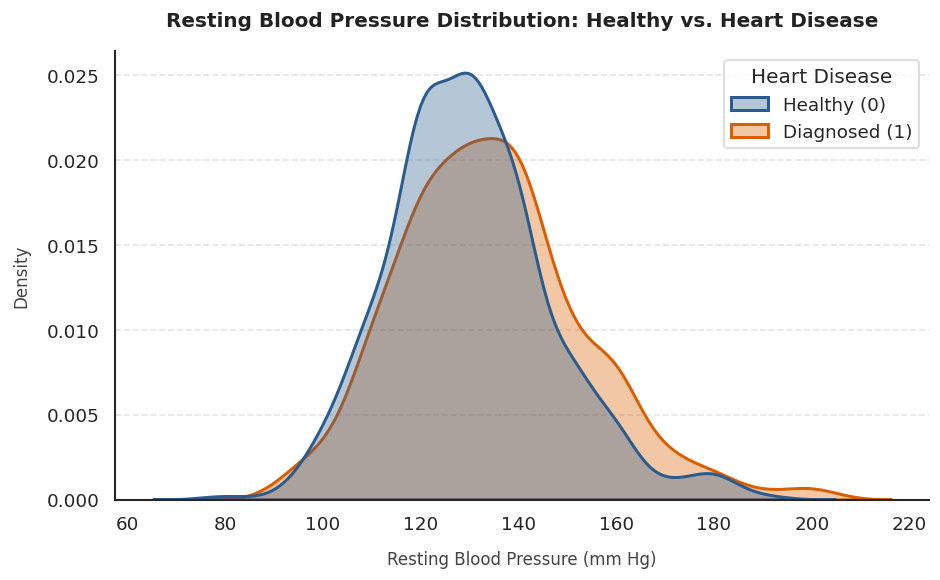

In [ ]:
plot_unified_kde(
    data=heart_df,
    x_col="RestingBP",
    hue_col="HeartDisease",
    title="Resting Blood Pressure Distribution: Healthy vs. Heart Disease",
    xlabel="Resting Blood Pressure (mm Hg)",
)

In [ ]:
# Hypothesis Testing: Is the Resting Blood Pressure of heart disease patients less than that of healthy patients?
# H0: There is no statistical significance in the difference between the RestingBP of heart disease patients and healthy patients.

from scipy.stats import t

healthy_rbp = heart_df[heart_df['HeartDisease'] == 0]['RestingBP']
disease_rbp = heart_df[heart_df['HeartDisease'] == 1]['RestingBP']

t_value = (disease_rbp.mean() - healthy_rbp.mean()) / np.sqrt((healthy_rbp.std() ** 2 / len(healthy_rbp)) + (disease_rbp.std() ** 2 / len(disease_rbp)))

degrees_of_freedom = len(healthy_rbp) + len(disease_rbp) - 2

p_value = t.cdf(t_value, degrees_of_freedom)

print(p_value)

if p_value < 0.05:
    print("Conclusion: Reject H0. There is a statistically significant difference in RestingBP.")

0.9998593553189096


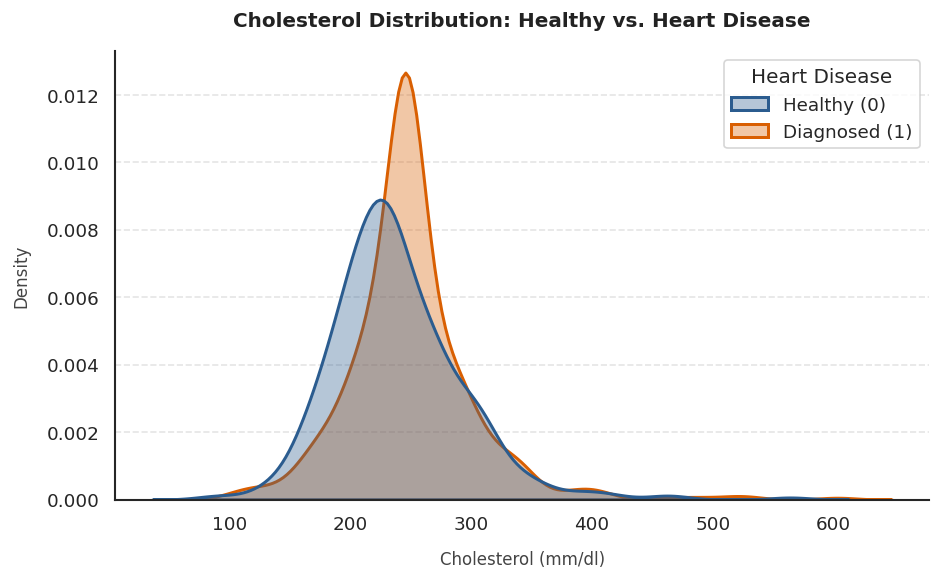

In [ ]:
plot_unified_kde(
    data=heart_df,
    x_col="Cholesterol",
    hue_col="HeartDisease",
    title="Cholesterol Distribution: Healthy vs. Heart Disease",
    xlabel="Cholesterol (mm/dl)",
)

In [ ]:
# Hypothesis Testing: Is the Cholesterol of heart disease patients less than that of healthy patients?
# H0: There is no statistical significance in the difference between the Cholesterol of heart disease patients and healthy patients.

from scipy.stats import t

healthy_chol = heart_df[heart_df['HeartDisease'] == 0]['Cholesterol']
disease_chol = heart_df[heart_df['HeartDisease'] == 1]['Cholesterol']

t_value = (disease_chol.mean() - healthy_chol.mean()) / np.sqrt((healthy_chol.std() ** 2 / len(healthy_chol)) + (disease_chol.std() ** 2 / len(disease_chol)))

degrees_of_freedom = len(healthy_chol) + len(disease_chol) - 2

p_value = t.cdf(t_value, degrees_of_freedom)

print(p_value)

if p_value < 0.05:
    print("Conclusion: Reject H0. There is a statistically significant difference in RestingBP.")

0.9991491083583827


## **Classification by Random Forest**

In [ ]:
# No scaling needed for Random Forest -- tree splits are scale-invariant.
X_rf = heart_df[['Age','RestingBP','Cholesterol','FastingBS','MaxHR','Oldpeak','Male','Angina','SlopeUp','ChestPainType_ATA','ChestPainType_NAP','ChestPainType_TA','RestingECG_Normal','RestingECG_ST']]
y_rf = heart_df['HeartDisease']

print("RF feature matrix shape:", X_rf.shape)

RF feature matrix shape: (918, 14)


In [ ]:
# Train-Test Split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# Stratify to preserve class proportions in the split
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=42, stratify=y_rf
)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    class_weight='balanced',   # extra safety net on top of the quantile bins
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_rf, y_train_rf)

y_pred_rf = rf.predict(X_test_rf)
print(f"Accuracy: {accuracy_score(y_test_rf, y_pred_rf):.3f}")
print()
print(classification_report(y_test_rf, y_pred_rf))

Accuracy: 0.891

              precision    recall  f1-score   support

           0       0.89      0.87      0.88        82
           1       0.89      0.91      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184



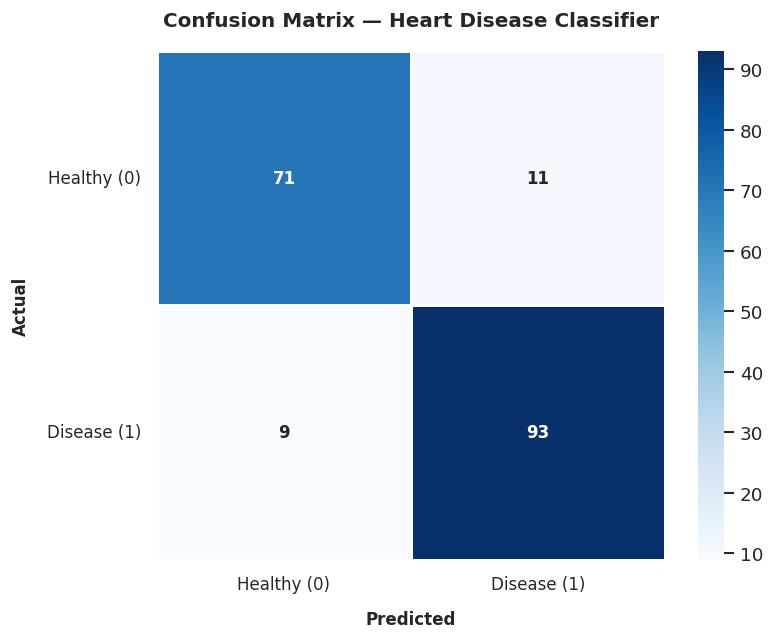

In [ ]:
# Confusion Matrix
labels_order = [0,1]
cm = confusion_matrix(y_test_rf, y_pred_rf, labels=labels_order)

# Standard Matrix Array: [[TN, FP], [FN, TP]]

# Calculate percentages over total sample size
cm_sum = np.sum(cm)
cm_perc = cm / cm_sum * 100

# --- Plotting ---
fig, ax = plt.subplots(figsize=(7, 5.5))

sns.heatmap(
    cm,
    annot = True,
    fmt="",  # Uses string formatting from labels array
    cmap="Blues",
    cbar=True,
    square=True,
    linewidths=1.5,
    linecolor="white",
    annot_kws={"fontsize": 10, "fontweight": "bold"},
    ax=ax,
)

# Axis Labels & Tick Marks
ax.set_title(
    "Confusion Matrix — Heart Disease Classifier",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Predicted", fontsize=10, fontweight="bold", labelpad=10)
ax.set_ylabel("Actual", fontsize=10, fontweight="bold", labelpad=10)

ax.xaxis.set_ticklabels(["Healthy (0)", "Disease (1)"], fontsize=10)
ax.yaxis.set_ticklabels(
    ["Healthy (0)", "Disease (1)"], fontsize=10, rotation=0
)

plt.tight_layout()
plt.show()

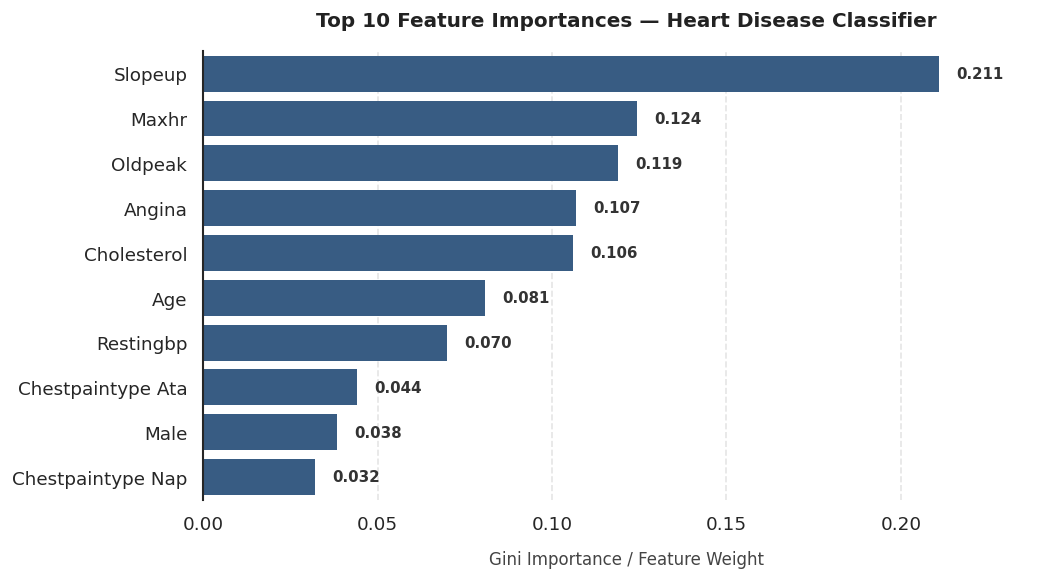

In [ ]:
# Feature Importance
importances = pd.Series(rf.feature_importances_, index=X_rf.columns)
top_importances = importances.sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9, 5))

# Format feature names for clean display
clean_labels = [label.replace('_', ' ').title() for label in top_importances.index]

# Draw Barplot with consistent styling
bars = sns.barplot(
    x=top_importances.values,
    y=clean_labels,
    color='#2b5c8f',  # Matching the Navy palette from KDE plots
    edgecolor='none',
    ax=ax
)

# Add exact value labels on the tips of bars
for bar in bars.patches:
    width = bar.get_width()
    ax.text(
        width + 0.005,  # Slight offset to the right of the bar
        bar.get_y() + bar.get_height() / 2,
        f'{width:.3f}',
        va='center',
        ha='left',
        fontsize=9,
        color='#333333',
        fontweight='bold'
    )

# Spines & Gridlines
sns.despine(top=True, right=True, left=False, bottom=True)  # Clean framing
ax.xaxis.grid(True, linestyle='--', alpha=0.5, color='#cccccc')  # Subtle vertical grid
ax.set_axisbelow(True)  # Keep grid lines behind bars

# Professional Titles & Axis Labels
ax.set_title('Top 10 Feature Importances — Heart Disease Classifier',
             fontsize=12, fontweight='bold', pad=15, color='#222222')
ax.set_xlabel('Gini Importance / Feature Weight', fontsize=10, labelpad=10, color='#444444')
ax.set_ylabel('', fontsize=10)

# Expand x-limit slightly so labels aren't clipped by the right border
ax.set_xlim(0, max(top_importances.values) * 1.15)

plt.tight_layout()
plt.show()

## **Classification by Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(X_rf, y_rf, test_size=0.20, random_state=23)

clf = LogisticRegression(max_iter=300, random_state=0)
clf.fit(X_train, y_train)

y_pred_lr = clf.predict(X_test_rf)
print(f"Accuracy: {accuracy_score(y_test_rf, y_pred_lr):.3f}")
print()
print(classification_report(y_test_rf, y_pred_lr))

Accuracy: 0.870

              precision    recall  f1-score   support

           0       0.86      0.84      0.85        82
           1       0.88      0.89      0.88       102

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## **Anomaly Detection**

In [ ]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

# only continuous variables
lof_features = ['Age','RestingBP','Cholesterol','FastingBS','MaxHR', 'Oldpeak']
X_lof = heart_df[lof_features].copy()

scaler_lof = StandardScaler()
X_lof_scaled = scaler_lof.fit_transform(X_lof)

lof = LocalOutlierFactor(n_neighbors=50, contamination=0.02)
lof_labels = lof.fit_predict(X_lof_scaled)
lof_scores = lof.negative_outlier_factor_

heart_df['lof_anomaly'] = lof_labels
heart_df['lof_score'] = lof_scores

anomalies = heart_df[heart_df['lof_anomaly'] == -1].sort_values('lof_score')
print(f"Number of anomalies flagged: {len(anomalies)}")
anomalies[['HeartDisease', 'Age','RestingBP','Cholesterol','FastingBS','MaxHR']].head(10)

Number of anomalies flagged: 19


,HeartDisease,Age,RestingBP,Cholesterol,FastingBS,MaxHR
76,1,32,118.0,529.0,0,130
149,1,54,130.0,603.0,1,125
616,0,67,115.0,564.0,0,160
541,1,76,104.0,113.0,0,120
850,1,62,160.0,164.0,0,145
496,0,58,132.0,458.0,1,69
103,1,40,120.0,466.0,1,152
30,1,53,145.0,518.0,0,130
250,1,44,135.0,491.0,0,135
28,0,53,113.0,468.0,0,127


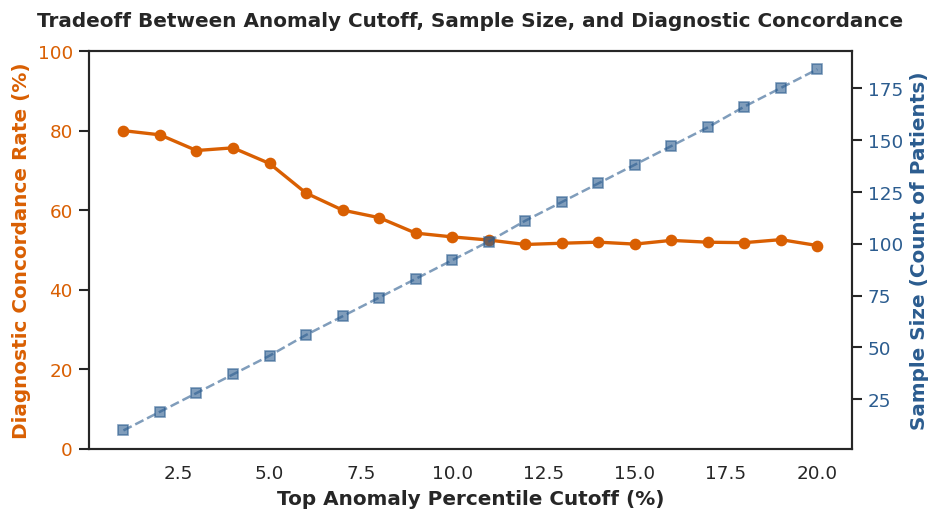

In [ ]:
# Define a range of top-percentile cutoffs to test
percentiles = np.arange(1, 21, 1)  # Top 1% to Top 20%
concordance_rates = []
sample_sizes = []

for p in percentiles:
    cutoff = np.percentile(heart_df['lof_score'], 100 - p)
    anom_subset = heart_df[heart_df['lof_score'] >= cutoff]

    # Calculate % of anomalies that have HeartDisease == 1
    concordance = (anom_subset['HeartDisease'] == 1).mean() * 100

    concordance_rates.append(concordance)
    sample_sizes.append(len(anom_subset))

# --- Plotting the Tradeoff Curve ---
fig, ax1 = plt.subplots(figsize=(8, 4.5))

color = '#d95f02'
ax1.set_xlabel('Top Anomaly Percentile Cutoff (%)', fontweight='bold')
ax1.set_ylabel('Diagnostic Concordance Rate (%)', color=color, fontweight='bold')
ax1.plot(percentiles, concordance_rates, color=color, marker='o', linewidth=2, label='Concordance Rate')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(0, 100)

# Secondary axis for sample size
ax2 = ax1.twinx()
color = '#2b5c8f'
ax2.set_ylabel('Sample Size (Count of Patients)', color=color, fontweight='bold')
ax2.plot(percentiles, sample_sizes, color=color, linestyle='--', marker='s', alpha=0.6, label='Sample Size')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Tradeoff Between Anomaly Cutoff, Sample Size, and Diagnostic Concordance', pad=15, fontweight='bold')
fig.tight_layout()
plt.show()

# We select 2% as the top anomaly percentile cutoff.

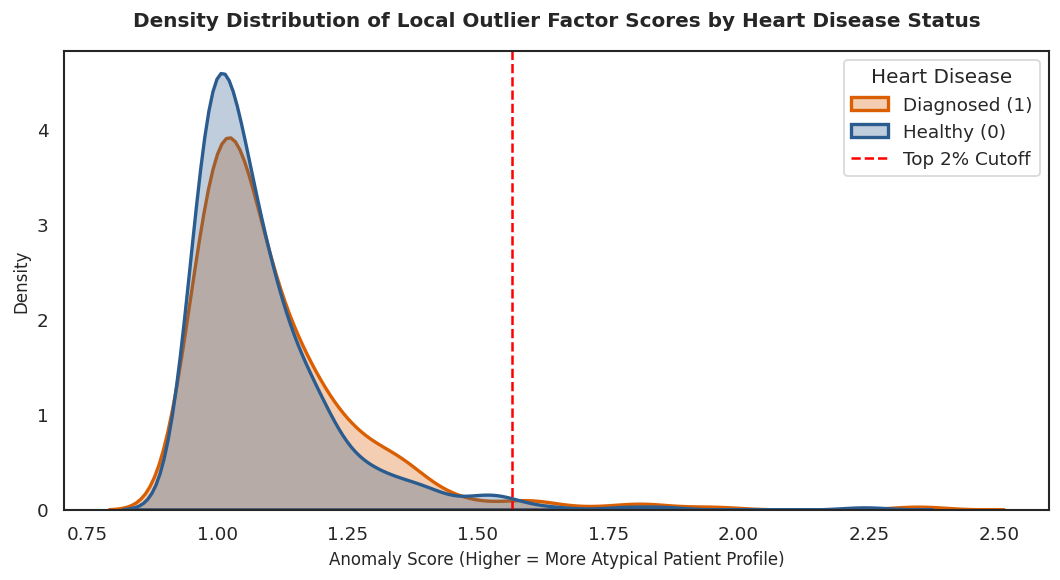

In [ ]:
heart_df['lof_score'] = -1 * lof_scores

# --- Step 3: KDE Density Plot ---
plt.figure(figsize=(9, 5))

# Plot KDE split by HeartDisease status
sns.kdeplot(
    data=heart_df,
    x='lof_score',
    hue='HeartDisease',
    common_norm=False,      # Normalizes each curve individually
    fill=True,
    alpha=0.3,
    palette=['#2b5c8f', '#d95f02'],  # Professional Navy vs. Burnt Orange palette
    linewidth=2
)

# Add a threshold reference line (e.g., top 0.5% anomaly threshold)
threshold = np.percentile(heart_df['lof_score'], 98)
plt.axvline(
    x=threshold,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f'90th Percentile Threshold ({threshold:.2f})'
)

# Annotations & Formatting
plt.title('Density Distribution of Local Outlier Factor Scores by Heart Disease Status', fontsize=12, pad=15, fontweight='bold')
plt.xlabel('Anomaly Score (Higher = More Atypical Patient Profile)', fontsize=10)
plt.ylabel('Density', fontsize=10)
plt.legend(title='Heart Disease', labels=['Diagnosed (1)', 'Healthy (0)', 'Top 2% Cutoff'])
plt.tight_layout()
plt.show()

In [ ]:
# Mean cholesterol in the anomalous group (Top 2%)
anomaly_chol_mean = heart_df[heart_df['lof_anomaly'] == -1]['Cholesterol'].mean()

# Mean cholesterol in the baseline group (Remaining 98%)
baseline_chol_mean = heart_df[heart_df['lof_anomaly'] == 1]['Cholesterol'].mean()

print(f"Top 10% Anomaly Mean Cholesterol: {anomaly_chol_mean:.1f} mg/dL")
print(f"Baseline Mean Cholesterol: {baseline_chol_mean:.1f} mg/dL")

Top 10% Anomaly Mean Cholesterol: 350.3 mg/dL
Baseline Mean Cholesterol: 242.3 mg/dL


In [ ]:
# Filter for the top 2% anomaly group
anomalies_only = heart_df[heart_df['lof_anomaly'] == -1]

# Calculate percentage with HeartDisease == 1
concordance_rate = (anomalies_only['HeartDisease'] == 1).mean() * 100

print(f"Diagnostic Concordance Rate: {concordance_rate:.1f}%")

Diagnostic Concordance Rate: 73.7%
